In [ ]:
# MIT License
#
#@title Copyright (c) 2026 CCAI Community Authors { display-mode: "form" }
#
# Permission is hereby granted, free of charge, to any person obtaining a
# copy of this software and associated documentation files (the "Software"),
# to deal in the Software without restriction, including without limitation
# the rights to use, copy, modify, merge, publish, distribute, sublicense,
# and/or sell copies of the Software, and to permit persons to whom the
# Software is furnished to do so, subject to the following conditions:
#
# The above copyright notice and this permission notice shall be included in
# all copies or substantial portions of the Software.
#
# THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
# IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
# FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL
# THE AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
# LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING
# FROM, OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER
# DEALINGS IN THE SOFTWARE.

# CCAI Summer School Tutorial | AI for Climate Finance: Estimating Hurricane Wind Value-at-Risk from an AI Weather Ensemble

> **CCAI Virtual Summer School 2026 — _AI for Climate Finance_**

> **Author:** Tristan Ballard, PhD | Zeus AI  

**Module:** Physical Climate Risk & Catastrophe Modeling

---

Hurricanes are among the costliest natural disasters on Earth, and the financial institutions that insure homes, hold mortgages, or invest in coastal regions need **forward-looking, quantified estimates** of the losses a storm might cause — *before* it makes landfall, sometimes before it even has a name.

In this tutorial you will turn an **ensemble of AI-generated hurricane forecasts** (Google's experimental _WeatherNext_ cyclone model, 50 members, for the system that became **Hurricane Helene, 2024**) into a **county-level Climate Value-at-Risk** for single-family-home wind damage across Florida, Georgia, South Carolina, and North Carolina.

We follow the standard catastrophe-modeling chain — **hazard → exposure → vulnerability → loss** — running it once per ensemble member to build a *distribution* of possible losses per county, then reading a percentile off that distribution: the **Value-at-Risk**.

### By the end of this tutorial you will be able to…

1. **Explain** what Climate Value-at-Risk (VaR) is and why a financial institution needs a *distribution* of losses, not a single number.
2. **Adapt** raw AI weather-model output (a generative cyclone ensemble) into a form a catastrophe model can consume.
3. **Run** the four-stage hazard → exposure → vulnerability → loss pipeline using the open-source [CLIMADA](https://climada.ethz.ch/) platform.
4. **Compute** a per-county wind VaR from a 50-member forecast ensemble and interpret how the percentile choice changes the answer.
5. **Visualize** the result as a choropleth map and read the spatial story it tells.
6. **Critique** the result responsibly — recognizing that a *wind-only* model systematically *understates* a flood-driven disaster like Helene, and articulating what is needed before any real-world use.

⏱️ **Time to complete:** ~2 hours · **Wall-clock run time:** a few minutes.

## 0 · Setup & logistics

> 📌 **Before you start:** go to **File → Save a copy in Drive** so you keep your own editable version and your work is not lost.
>
> ▶️ This notebook runs top-to-bottom with **Runtime → Run all**. No manual edits or uploads are required — every dataset is bundled.

### A one-minute terminology key

This tutorial borrows vocabulary from catastrophe modeling and quantitative finance. We define each term in full the first time it appears, but here is the map up front:

| Term | Plain-language meaning |
|---|---|
| **Hazard** | The physical thing that can cause harm — here, hurricane **wind speed** at a location. |
| **Exposure** | The assets that can be damaged and their value — here, **single-family homes** per county. |
| **Vulnerability** | How much damage a given hazard intensity causes — a **damage function** mapping wind speed → fraction of value lost. |
| **Loss** | Exposure × damage fraction = **dollars of damage**. |
| **Ensemble** | A *set* of equally-plausible forecasts (here 50), capturing forecast **uncertainty**. |
| **Value-at-Risk (VaR)** | A loss threshold at a chosen confidence level: _"with 95% confidence, losses won't exceed \$Y."_ A **percentile of a loss distribution**. |

Don't worry if these are fuzzy now — each gets its own section below.

## 1 · Introduction — why physical climate risk is a financial problem

### The institutions on the hook

Insurers, banks, asset managers, and mortgage lenders all hold portfolios that are physically exposed to climate hazards: a hurricane that destroys homes hits a property insurer's claims, a mortgage lender's collateral, and a municipal-bond investor's tax base all at once. Regulators (and increasingly, their own risk committees) now require these institutions to produce **forward-looking, quantified estimates of potential climate-driven loss**.

### What "Value-at-Risk" means

> **Value-at-Risk (VaR)** is a loss threshold at a chosen confidence level. A "95% VaR of \$Y" means: *with 95% confidence, losses will not exceed \$Y* — equivalently, there is only a 5% chance of doing worse than \$Y.

The crucial point: **VaR is a percentile of a loss *distribution*, not a single number.** To compute it you first need a *range of possible outcomes*, and then you read off (say) the 95th percentile.

### Why a single forecast isn't enough — and why we use an AI *ensemble*

A single, deterministic hurricane track gives you exactly **one** loss number — a *scenario loss*. You cannot compute a percentile from one number.

An **ensemble** — many equally-plausible tracks — gives you a *distribution* of losses, and *that* is what VaR needs. This is precisely what a **generative / probabilistic AI weather model** produces. Google's *WeatherNext* cyclone model emits **50 ensemble members** for a single storm, each a complete, physically-plausible track-and-intensity forecast. The spread *between* members **is** the forecast uncertainty — exactly the raw material a VaR calculation consumes.

> 🤔 **Check your understanding.** If you had only the single "best-guess" track, which number could you report — a scenario loss or a VaR? *(Answer: only a scenario loss. VaR requires a distribution, hence an ensemble.)*


What we compute here is **loss uncertainty for one storm, given forecast spread** — a *forward-looking **event** VaR*. It is **not** an annualized, multi-storm *Average Annual Loss* (AAL), which is what an insurer would use to set an annual premium. Keeping this distinction straight is itself a piece of responsible practice: it is easy to over-read a single-event number as if it were an annual one.

## 2 · The pipeline at a glance

Every catastrophe model — whether a global reinsurer's or this teaching notebook's — is the same four-link chain. We add a fifth step to turn the per-member losses into a VaR:

```
  ┌───────────────────────────────────────────────────────────────────────┐
  │   AI WEATHER ENSEMBLE  (50 WeatherNext members for Helene)              │
  └───────────────────────────────────────────────────────────────────────┘
                                  │  one run PER MEMBER
                                  ▼
   ① HAZARD          wind speed at each county        (TropCyclone wind field)
        │
        ▼
   ② EXPOSURE        homes × value per county         (what can be damaged)
        │
        ▼
   ③ VULNERABILITY   wind speed → % damage            (the damage function)
        │
        ▼
   ④ LOSS            exposure × damage = $            (one $ per county PER member)
        │
        ▼   ... 50 loss numbers per county ...
   ⑤ VALUE-AT-RISK   95th percentile of the 50        (the headline output)
```

Steps ①–④ run **once per ensemble member**, so step ⑤ has a *distribution* of 50 loss values for every county. The VaR is a percentile of that distribution. Let's build it link by link.

**Where is the "AI/ML" in this pipeline?** The machine-learning component here is the generative weather model itself. WeatherNext is a large AI forecasting system produced by Google DeepMind, and its 50-member ensemble, the probabilistic hazard input this whole tutorial is built on, is its learned output. This mirrors real practice: modern AI weather-prediction models are so expensive to train that the overwhelming majority of practitioners consume their forecast outputs, as we do here, rather than training one themselves. Most leading AI weather models are developed by modeling groups at large technology companies (e.g. Google, NVIDIA, Microsoft) and research institutions (e.g. ECMWF), with a growing number of specialized startups such as Zeus AI entering the field. The downstream catastrophe chain (hazard → exposure → vulnerability → loss) is kept deliberately transparent and deterministic so you can see exactly how the AI-derived forecast uncertainty propagates into a financial risk number.

If you are interested in a hands-on exploration of AI weather models like WeatherNext, check out the Climate Change AI tutorial _FourCastNet: A practical introduction to a state-of-the-art deep learning global weather emulator_ running FourCastNet, a similar model created by NVIDIA.  

## 3 · Software requirements & installation

We use **[CLIMADA](https://climada.ethz.ch/)** (CLImate ADAptation), an open-source, peer-reviewed catastrophe-modeling platform from ETH Zürich. It gives us the tropical-cyclone wind model, the exposure/vulnerability containers, and the impact engine — the whole chain in one library.

> ⏱️ **This cell takes ~2–4 minutes** the first time (CLIMADA pulls a heavy geospatial stack — GDAL, rasterio, geopandas, pyproj). That is normal. ☕
>
> 🔧 **One pin that matters:** `fiona==1.9.4.post1`. CLIMADA 5.0 imports a function (`fiona.crs.from_epsg`) that newer fiona removed, so we pin fiona explicitly. Without it the install *succeeds* but `import climada` *fails* — a classic dependency-conflict trap worth seeing once.

In [3]:
import sys, subprocess
PKGS = ["climada", "codecarbon==2.5.1", "mapclassify==2.8.1"]  # no fiona pin; climada unpinned
print("Installing (Colab = py3.12)…")
res = subprocess.run([sys.executable, "-m", "pip", "install", *PKGS])  # no -q, no check
if res.returncode != 0:
    raise SystemExit("pip failed — read the message above")

Installing (Colab = py3.12)…
  Using cached climada-6.1.0-py3-none-any.whl.metadata (8.2 kB)
  Using cached codecarbon-2.5.1-py3-none-any.whl.metadata (8.4 kB)
  Using cached mapclassify-2.8.1-py3-none-any.whl.metadata (2.8 kB)
  Using cached pynvml-13.0.1-py3-none-any.whl.metadata (5.6 kB)
  Using cached bayesian_optimization-3.3.0-py3-none-any.whl.metadata (11 kB)
  Using cached bottleneck-1.6.0-cp312-cp312-macosx_11_0_arm64.whl.metadata (8.2 kB)
  Using cached cfgrib-0.9.15.1-py3-none-any.whl.metadata (56 kB)
  Using cached contextily-1.7.1-py3-none-any.whl.metadata (3.1 kB)
  Using cached deprecation-2.1.0-py2.py3-none-any.whl.metadata (4.6 kB)
  Using cached fiona-1.10.1-cp312-cp312-macosx_11_0_arm64.whl.metadata (56 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 8.9 MB/s  0:00:00 eta 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 31.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 22.1 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━

In [4]:
# --- Imports + reproducibility ------------------------------------------------
import warnings, logging, os
warnings.filterwarnings("ignore")            # keep the notebook output readable
logging.getLogger("climada").setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

np.random.seed(42)
print("numpy", np.__version__, "| pandas", pd.__version__, "| geopandas", gpd.__version__)

numpy 2.2.6 | pandas 3.0.3 | geopandas 1.1.4


## 4 · Data

Our pipeline needs three datasets, one per modeling stage. **All three are bundled** with this notebook (in `data/`) so nothing depends on a live download at run time.

### 4.1 Locate and download the key datasets

If you opened this notebook from the CCAI repository the `data/` folder is already beside it. The cell below also handles the bare-Colab case by fetching the files from the course mirror. You may also manually download the files by going to https://github.com/tristanballard/ccai-hurricane-var-data/tree/main/data.

In [5]:
from pathlib import Path
FILES = ["FNV3_2024_09_23T12_00_paired.csv",
         "sf_homes_by_county.csv",
         "counties_fl_ga_sc_nc.geojson"]

def has_all(d): return d.is_dir() and all((d / f).exists() for f in FILES)

# 1) local / session-upload layout
DATA_DIR = next((d for d in [Path("data"), Path("/content/data")] if has_all(d)), None)

# 2) my Google Drive layout
if DATA_DIR is None:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        d = Path("/content/drive/MyDrive/{path_to_personal_GoogleDrive_data}")
        if has_all(d): DATA_DIR = d
    except Exception:
        pass

# 3) public mirror (for anyone opening the notebook alone)
if DATA_DIR is None:
    import urllib.request
    DATA_DIR = Path("data"); DATA_DIR.mkdir(exist_ok=True)
    MIRROR = "https://raw.githubusercontent.com/tristanballard/ccai-hurricane-var-data/main/data/"
    for f in FILES:
        if not (DATA_DIR / f).exists():
            urllib.request.urlretrieve(MIRROR + f, DATA_DIR / f)

assert has_all(DATA_DIR), f"Data files not found in {DATA_DIR}"
print("Using data dir:", DATA_DIR)

Using data dir: data


### 4.2 The hazard data — WeatherNext FNV3 cyclone ensemble

- **What it is:** 50 ensemble members of a tropical-cyclone forecast for the system that became Hurricane Helene, initialized **2024-09-23 12:00 UTC** — roughly **three days before landfall**, when the storm was still an unnamed *invest* (`AL97`). An *invest* is the label forecasters give a disturbance they're watching before it's a named storm.
- **Source:** Google *WeatherNext* / DeepMind, experimental "FNV3" cyclone model.
- **Access:** The download link is https://deepmind.google.com/science/weatherlab/download/cyclones/FNV3/ensemble/paired/csv/FNV3_2024_09_23T12_00_paired.csv. You can access alternate track data at https://deepmind.google.com/science/weatherlab.
- **Key variables:** per 6-hourly track point — latitude, longitude, minimum sea-level pressure, maximum sustained wind, radius of maximum winds.
- **Units:** wind in **knots**, pressure in **hPa (≡ mb)**, radii in **km**.
- **Limitations:** experimental and **being deprecated (July 15 2026)**; a *forecast*, not an observation; the file also contains an unrelated East-Pacific storm we must filter out.

### 4.3 The exposure data — single-family homes per county

- **What it is:** the number of 1-unit detached homes in each county of FL/GA/SC/NC.
- **Source:** US Census **American Community Survey (ACS) 5-year, table B25024** (`B25024_002E` = "1-unit, detached"), bundled as `sf_homes_by_county.csv` so no live Census API call is needed.
- **Key variables:** county FIPS, state, home count, county representative-point latitude/longitude.

### 4.4 The vulnerability data — a residential wind damage function

- **What it is:** a curve mapping wind speed → mean fraction of a home's value lost.
- **Source:** a **USACE / HAZUS-style** residential wind curve (a sigmoid: ~negligible damage below ~50 mph, rising steeply, high by ~150+ mph). Defined here in mph and converted to m/s for CLIMADA.

---

### 📋 Datasheet

| | **WeatherNext FNV3 ensemble** | **Census ACS B25024** | **HAZUS-style wind curve** |
|---|---|---|---|
| **Source** | Google WeatherNext / DeepMind | US Census Bureau, ACS 5-yr 2022 | USACE / FEMA HAZUS literature |
| **Represents** | 50-member genesis forecast for Helene, init 2024-09-23 12:00 UTC | 1-unit detached homes by county | Mean damage ratio vs wind speed, US wood-frame residential |
| **License** | **CC BY 4.0** for data >48 h old (attribute Google); the 48 h "fresh" window is governed by [WeatherNext Terms of Use](https://storage.googleapis.com/weathernext-public/terms-of-use.pdf) | Public domain (US Govt) | Public / literature |
| **Provenance** | Experimental cyclone model output, paired-track CSV | Census API → bundled CSV | Parameterized to literature anchor points |
| **Key limitations** | Experimental, **deprecating Jul 2026**, forecast ≠ observation | 5-yr estimate, has sampling error, counts ≠ values | Idealized, US-generic, gust-vs-sustained mismatch (see §7) |


## Step 1 · Load & explore the WeatherNext ensemble

Before adapting anything, let's *look* at the raw forecast. The CSV has a short license **preamble** ending in a `# BEGIN DATA` line; the real column header follows it. We find that line programmatically rather than hard-coding a row number — real model output often carries variable-length headers.

In [6]:
# --- Peek at the file preamble --------
HAZARD_CSV = DATA_DIR / "FNV3_2024_09_23T12_00_paired.csv"
with open(HAZARD_CSV) as fh:
    for i, line in enumerate(fh):
        print(repr(line.rstrip()))
        if line.strip() == "# BEGIN DATA":
            print(f"   ↑ real header starts on the NEXT line (line {i+1})")
            break

'# If this file contains data that relates to a time no more than 48 hours ago,'
'# BY USING IT YOU AGREE TO THE LEGALLY BINDING TERMS OF USE FOUND AT'
'#   https://storage.googleapis.com/weathernext-public/terms-of-use.pdf'
'# Any data that relates to a time more than 48 hours ago is licensed under the'
'# Creative Commons Attribution International License, Version 4.0 (CC BY 4.0).'
'# BEGIN DATA'
   ↑ real header starts on the NEXT line (line 6)


In [7]:
# --- Find the data start, then load the table --------------------------------
def find_data_start(path):
    """Return #lines to skip so the real column header is the first row read."""
    with open(path) as fh:
        for i, line in enumerate(fh):
            if line.strip() == "# BEGIN DATA":
                return i + 1
    raise ValueError("Could not find '# BEGIN DATA' marker.")

raw = pd.read_csv(HAZARD_CSV, skiprows=find_data_start(HAZARD_CSV))
print("rows:", len(raw), "| storms in file:", list(raw.track_id.unique()))
raw.head(3)

rows: 1824 | storms in file: ['AL972024', 'EP102024']


,init_time,track_id,sample,valid_time,lead_time,lat,lon,minimum_sea_level_pressure_hpa,maximum_sustained_wind_speed_knots,radius_of_maximum_winds_km,...,radius_34_knot_winds_sw_km,radius_34_knot_winds_nw_km,radius_50_knot_winds_ne_km,radius_50_knot_winds_se_km,radius_50_knot_winds_sw_km,radius_50_knot_winds_nw_km,radius_64_knot_winds_ne_km,radius_64_knot_winds_se_km,radius_64_knot_winds_sw_km,radius_64_knot_winds_nw_km
0,2024-09-23 12:00:00,AL972024,0.0,2024-09-23 12:00:00,0 days 00:00:00,17.20,-81.70,1004.0,30.0,185.199933,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-09-23 12:00:00,EP102024,0.0,2024-09-23 12:00:00,0 days 00:00:00,14.60,-98.40,992.0,60.0,37.039987,...,55.559980,55.559980,37.039987,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
2,2024-09-23 12:00:00,EP102024,0.0,2024-09-23 18:00:00,0 days 06:00:00,15.21,-98.48,983.5,66.2,19.151709,...,80.234314,84.941917,37.896446,31.979959,22.633886,30.127172,5.055135,3.385343,2.218746,4.154748


Notice **two** `track_id`s. `AL972024` is the Atlantic system that became Helene; `EP102024` is an *unrelated East-Pacific storm* that happened to be in the same forecast file. **Lesson:** real model output tracks multiple systems at once — selecting *your* storm is step one of every catastrophe study.

Let's filter to our storm and look at the ensemble's **landfall-intensity spread** — the very uncertainty that will become our VaR.

In [8]:
# --- Filter to our storm and inspect the intensity spread --------------------
al = raw[raw.track_id == "AL972024"].copy()
al["valid_time"] = pd.to_datetime(al["valid_time"])

n_members = al["sample"].nunique()
peak_wind_kn = al.groupby("sample").maximum_sustained_wind_speed_knots.max()

print(f"Ensemble members for AL97: {n_members}")
print(f"Peak sustained wind across members: "
      f"{peak_wind_kn.min():.0f}–{peak_wind_kn.max():.0f} kn "
      f"(median {peak_wind_kn.median():.0f} kn)")

Ensemble members for AL97: 50
Peak sustained wind across members: 30–130 kn (median 112 kn)


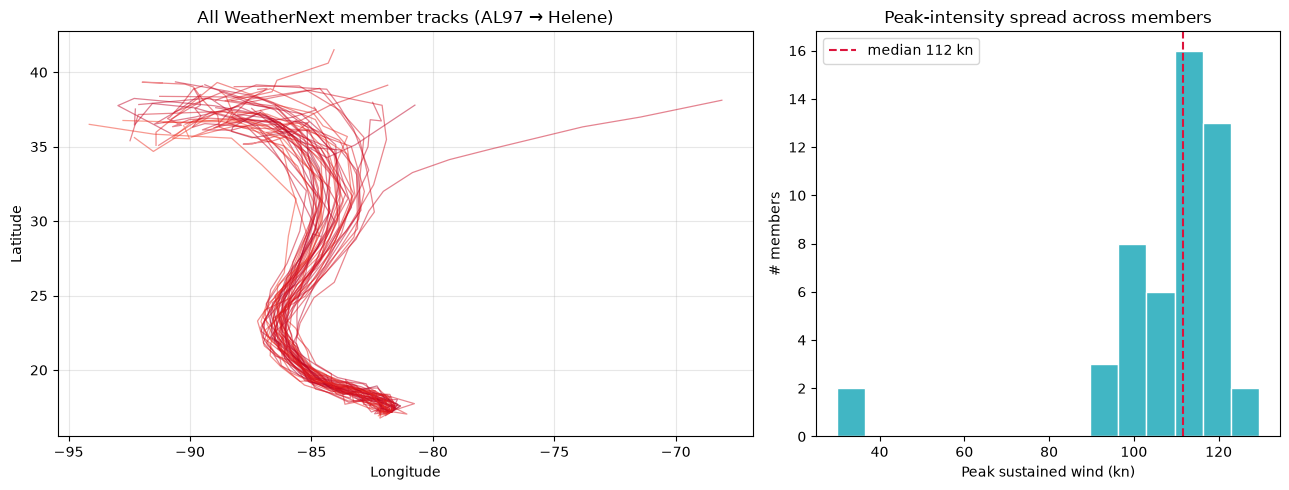

In [9]:
# --- EDA plot: all member tracks + the peak-intensity histogram --------------
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 5),
                               gridspec_kw={"width_ratios": [1.5, 1]})

# (A) every member's track, colored by its peak wind
for s, g in al.groupby("sample"):
    g = g.sort_values("valid_time")
    axA.plot(g.lon, g.lat, lw=0.9, alpha=0.5,
             color=plt.cm.YlOrRd(min(g.maximum_sustained_wind_speed_knots.max()/140, 1)))
axA.set_title("All WeatherNext member tracks (AL97 → Helene)")
axA.set_xlabel("Longitude"); axA.set_ylabel("Latitude")
axA.grid(alpha=0.3)

# (B) spread of peak intensity = the forecast uncertainty
axB.hist(peak_wind_kn, bins=15, color="#41b6c4", edgecolor="white")
axB.axvline(peak_wind_kn.median(), color="crimson", ls="--",
            label=f"median {peak_wind_kn.median():.0f} kn")
axB.set_title("Peak-intensity spread across members")
axB.set_xlabel("Peak sustained wind (kn)"); axB.set_ylabel("# members")
axB.legend()
plt.tight_layout(); plt.show()

> 🤔 **Check your understanding.** The histogram on the right is *the reason this tutorial exists*. Each bar is a possible future. A risk manager who saw only the median (the dashed line) would miss the members on the high-wind tail — and the tail is exactly where the costly outcomes live.

## Step 2 · Adapt the tracks to CLIMADA's format

CLIMADA represents tropical-cyclone tracks as a list of `xarray.Dataset`s with a **specific schema** (specific variable names, units, and attributes). Raw WeatherNext output does not match that schema, so we write **one bespoke adapter function**. This is the only truly custom piece of the pipeline, and each cleaning step is a teaching point:

1. **Two storms in the file** → filter to `AL972024` (done in Step 1's spirit; the adapter re-applies it so it is self-contained).
2. **Helene wasn't named yet** → it's the invest `AL97`. We are pricing risk for a storm that *does not officially exist yet* — a powerful climate-finance capability and a humbling reminder of forecast uncertainty.
3. **Degenerate members** → a few `samples` have fewer than 3 track points and can't form a usable track; we drop them.

Unit conversions to match CLIMADA exactly:

| CLIMADA field | Source column | Conversion |
|---|---|---|
| `max_sustained_wind` | `maximum_sustained_wind_speed_knots` | none (unit `kn`) |
| `central_pressure` | `minimum_sea_level_pressure_hpa` | none (hPa ≡ mb) |
| `radius_max_wind` | `radius_of_maximum_winds_km` | **× 0.539957** (km → nautical miles) |
| `environmental_pressure` | — | synthesized constant **1010 mb** |
| `time_step` | `valid_time` differences | hours between points (≈6) |

In [10]:
# --- The bespoke adapter: WeatherNext CSV  →  CLIMADA TCTracks ----------------
from climada.hazard import TCTracks

KN_PER_KM = 0.539957          # 1 km = 0.539957 nautical miles
ENV_PRESSURE_MB = 1010.0      # synthesized constant environmental pressure


def _saffir_simpson(max_wind_kn):
    """Saffir–Simpson category from peak sustained wind (kn). -1=TD, 0=TS, 1–5."""
    if np.isnan(max_wind_kn):
        return -1
    for thr, cat in [(137, 5), (113, 4), (96, 3), (83, 2), (64, 1), (34, 0)]:
        if max_wind_kn >= thr:
            return cat
    return -1


def _member_to_dataset(member, sample):
    """Build one CLIMADA-schema xarray.Dataset for a single ensemble member."""
    member = member.sort_values("valid_time")
    time = member["valid_time"].values.astype("datetime64[ns]")

    dt_h = np.diff(time).astype("timedelta64[h]").astype(float)
    time_step = np.concatenate([[dt_h[0]], dt_h]) if len(dt_h) else np.array([6.0])

    max_wind = member["maximum_sustained_wind_speed_knots"].to_numpy(float)
    return xr.Dataset(
        data_vars=dict(
            max_sustained_wind=("time", max_wind),
            central_pressure=("time", member["minimum_sea_level_pressure_hpa"].to_numpy(float)),
            radius_max_wind=("time", member["radius_of_maximum_winds_km"].to_numpy(float) * KN_PER_KM),
            environmental_pressure=("time", np.full(len(member), ENV_PRESSURE_MB)),
            time_step=("time", time_step),
            basin=("time", np.full(len(member), "NA", dtype="<U2")),
        ),
        coords=dict(
            time=("time", time),
            lat=("time", member["lat"].to_numpy(float)),
            lon=("time", member["lon"].to_numpy(float)),
        ),
        attrs=dict(
            max_sustained_wind_unit="kn", central_pressure_unit="mb",
            name=f"AL97_m{int(sample)}", sid=f"AL97_m{int(sample)}",
            orig_event_flag=False, data_provider="WeatherNext_FNV3",
            basin="NA", id_no=int(sample), category=_saffir_simpson(np.nanmax(max_wind)),
        ),
    )


def weathernext_csv_to_tctracks(path, storm_id="AL972024", min_points=3):
    """Convert a WeatherNext FNV3 paired-CSV into a CLIMADA TCTracks object.

    Inputs
    ------
    path : str | Path   Bundled FNV3 paired CSV (with license preamble).
    storm_id : str      Track id to keep ('AL972024' → the future Helene).
    min_points : int    Minimum track points to keep a member (default 3).

    Output
    ------
    climada.hazard.TCTracks   One Dataset per surviving member, densified to 1-hourly.
    """
    df = pd.read_csv(path, skiprows=find_data_start(path))
    df = df[df["track_id"] == storm_id].copy()                      # (1) select our storm
    df["valid_time"] = pd.to_datetime(df["valid_time"])
    df = df.sort_values(["sample", "valid_time"])
    counts = df.groupby("sample")["valid_time"].transform("size")
    df = df[counts >= min_points].copy()                            # (3) drop degenerate members

    tracks = TCTracks()
    tracks.data = [_member_to_dataset(g, s) for s, g in df.groupby("sample")]
    tracks.equal_timestep(time_step_h=1)        # densify 6-hourly → 1-hourly before wind field
    return tracks


tracks = weathernext_csv_to_tctracks(HAZARD_CSV)
assert 40 <= tracks.size <= 50, f"expected 40-something members, got {tracks.size}"
print(f"✓ {tracks.size} usable ensemble members "
      f"(of 50; {50 - tracks.size} dropped: 2 degenerate + EP10 was never AL97)")
print(f"✓ densified to 1-hourly: member 0 now has {tracks.data[0].time.size} points")

✓ 48 usable ensemble members (of 50; 2 dropped: 2 degenerate + EP10 was never AL97)
✓ densified to 1-hourly: member 0 now has 109 points


> ⏱️ The next cell plots the adapted tracks — a quick visual sanity check that we have 40-something members sweeping **Florida → Georgia → the Carolinas**.

In [11]:
# --- Validate: the adapted tracks should sweep FL → GA → Carolinas -----------
ax = tracks.plot()
ax.set_title(f"Adapted CLIMADA tracks — {tracks.size} WeatherNext members")
plt.show()

GEOSException: IllegalArgumentException: Points of LinearRing do not form a closed linestring

<Figure size 900x1300 with 1 Axes>

## Step 3 · Generate the wind field (the **hazard**)

> **Hazard** = the physical intensity that can cause damage. Here it is the **peak wind gust (m/s)** each county experiences as the storm passes.

**Centroids = one representative point per county.** Rather than a fine grid, we put a single point in each of the ~372 counties of FL/GA/SC/NC. This keeps the hazard matrix tiny (≈372 points × 48 members) so the whole notebook runs in a few minutes.

> ⚠️ **Simplification to name out loud:** intra-county wind variation is ignored — every home in a county gets the *same* wind value (its county point's). A coastal county's beachfront and inland edge are treated identically. *(A finer grid is offered as an optional exercise at the end.)*

CLIMADA's `TropCyclone.from_tracks` superposes a parametric wind profile along every track point and returns a sparse **(events × centroids)** matrix — one event per ensemble member. We then set **equal event frequencies** `1/N` so all members are equally likely; the spread across events is then exactly our forecast loss distribution.

> 🛟 **Robustness flag — `USE_CLIMADA_HAZARD`.** CLIMADA is our primary engine. If its install ever fails in a future Colab, flip the flag below to `False` and an equivalent **self-contained Holland (1980) parametric wind model** (pure NumPy, ~40 lines) runs instead — same shape of output, no heavy install. We keep both so the tutorial can never hard-fail at the hazard step.

In [12]:
# --- Load the county exposure table (also gives us the centroid points) ------
homes = pd.read_csv(DATA_DIR / "sf_homes_by_county.csv")
homes["fips"] = homes["fips"].astype(str).str.zfill(5)
print(f"{len(homes)} counties | {homes.n_single_family_homes.sum():,} single-family homes")
homes.head(3)

372 counties | 12,980,579 single-family homes


,fips,county_name,state,n_single_family_homes,latitude,longitude
0,12001,Alachua,FL,63439,29.633690,-82.354656
1,12003,Baker,FL,5867,30.255752,-82.254446
2,12005,Bay,FL,53591,30.162583,-85.592894


In [13]:
# === HAZARD ENGINE FLAG =======================================================
USE_CLIMADA_HAZARD = True   # ← primary path. Set False to use the Holland fallback.
# ==============================================================================
N_MEMBERS = tracks.size

# --- Start CodeCarbon around the compute-heavy section (Steps 3-7) -----------
# Wrapped in try/except so a Colab runtime that can't read hardware power never
# breaks the notebook; we recover the number in §10.
_emissions_kg = None
try:
    from codecarbon import EmissionsTracker
    _tracker = EmissionsTracker(save_to_file=False, log_level="error")
    _tracker.start()
    print("CodeCarbon tracker started (covers the wind field → VaR computation).")
except Exception as _e:
    _tracker = None
    print(f"CodeCarbon unavailable, continuing without it: {_e}")

CodeCarbon unavailable, continuing without it: No module named 'pkg_resources'


In [14]:
# --- Self-contained Holland (1980) fallback wind model (pure NumPy) ----------
# Reference: Holland (1980), Mon. Wea. Rev. 108, 1212-1218.
RHO_AIR, KN_TO_MS = 1.15, 0.514444
GUST_FACTOR, GRADIENT_TO_SURFACE = 1.15, 0.90


def _haversine_km(lat1, lon1, lat2, lon2):
    r = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, (lat1, lon1, lat2, lon2))
    a = (np.sin((lat2 - lat1) / 2) ** 2
         + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2)
    return 2 * r * np.arcsin(np.sqrt(a))


def _holland_profile(r_km, pc_mb, penv_mb, rmax_km, vmax_ms, lat_deg):
    dp = np.maximum((penv_mb - pc_mb) * 100.0, 1.0)               # Pa
    b = np.clip((vmax_ms ** 2) * RHO_AIR * np.e / dp, 1.0, 2.5)   # Holland B
    r_km = np.maximum(r_km, 1e-3)
    rr = rmax_km / r_km
    f = 2 * 7.292e-5 * np.sin(np.radians(abs(lat_deg)))
    r_m = r_km * 1000.0
    inner = (b / RHO_AIR) * (rr ** b) * dp * np.exp(-(rr ** b))
    return np.maximum(np.sqrt(np.maximum(inner + (r_m * f / 2) ** 2, 0)) - r_m * f / 2, 0)


def holland_wind_field(tracks_df, lats, lons):
    """Peak gust (m/s), shape (n_members, n_points). Mirrors the CLIMADA output."""
    lats, lons = np.asarray(lats, float), np.asarray(lons, float)
    members = sorted(tracks_df["sample"].unique())
    out = np.zeros((len(members), len(lats)))
    for mi, s in enumerate(members):
        peak = np.zeros(len(lats))
        for _, row in tracks_df[tracks_df["sample"] == s].iterrows():
            vmax = row["maximum_sustained_wind_speed_knots"] * KN_TO_MS
            if not np.isfinite(vmax) or vmax <= 0:
                continue
            r = _haversine_km(row["lat"], row["lon"], lats, lons)
            v = _holland_profile(r, row["minimum_sea_level_pressure_hpa"], 1010.0,
                                 row["radius_of_maximum_winds_km"], vmax, row["lat"])
            peak = np.maximum(peak, v * GRADIENT_TO_SURFACE * GUST_FACTOR)
        out[mi] = peak
    return out, members

In [15]:
# --- Manually seed CLIMADA's distance-to-coast raster so it doesn't hit the dead NASA
# host (403). Powers the TropCyclone land-decay step. This may become unnecessary
# if https://oceancolor.gsfc.nasa.gov/docs/distfromcoast/GMT_intermediate_coast_distance_01d.zip
# comes back online.

if USE_CLIMADA_HAZARD:
    from climada.util.constants import SYSTEM_DIR
    from pathlib import Path
    import urllib.request, zipfile

    COAST_URL = ("https://github.com/tristanballard/ccai-hurricane-var-data/"
                 "releases/download/distance-to-coast-v1/"
                 "GMT_intermediate_coast_distance_01d.zip")
    _tif = Path(SYSTEM_DIR) / "GMT_intermediate_coast_distance_01d.tif"

    if not _tif.exists():
        print("downloading distance-to-coast raster (~328 MB)…")
        _zip = Path(SYSTEM_DIR) / "GMT_intermediate_coast_distance_01d.zip"
        urllib.request.urlretrieve(COAST_URL, _zip)
        with zipfile.ZipFile(_zip) as zf:
            zf.extractall(SYSTEM_DIR)
        print(f"✓ placed distance-to-coast raster in {SYSTEM_DIR}")
    else:
        print("✓ distance-to-coast raster already present")

# --- Build the wind field (events × counties) via the selected engine --------
# ⏱️ ~30-90 s for the CLIMADA path on first run (it caches a coastline geometry).
from scipy import sparse

if USE_CLIMADA_HAZARD:
    from climada.hazard import TropCyclone, Centroids
    centroids = Centroids.from_lat_lon(homes.latitude.values, homes.longitude.values)
    haz = TropCyclone.from_tracks(tracks, centroids=centroids)
    haz.frequency = np.full(haz.size, 1.0 / haz.size)      # equiprobable members
    intensity = haz.intensity                               # sparse (events × counties), m/s
    engine = "CLIMADA TropCyclone"
else:
    al_h = al.groupby("sample").filter(lambda g: len(g) >= 3)
    gust, _members = holland_wind_field(al_h, homes.latitude.values, homes.longitude.values)
    intensity = sparse.csr_matrix(gust)
    engine = "Holland (1980) fallback"

print(f"✓ wind field via {engine}: shape {intensity.shape} (events × counties)")
print(f"  max gust = {intensity.max():.1f} m/s "
      f"({intensity.max()/0.44704:.0f} mph) | nonzero entries = {intensity.nnz}")
assert intensity.shape[0] == N_MEMBERS and intensity.max() > 0, "wind field looks wrong"

downloading distance-to-coast raster (~328 MB)…
✓ placed distance-to-coast raster in /Users/adelagregan/climada/data
✓ wind field via CLIMADA TropCyclone: shape (48, 372) (events × counties)
  max gust = 59.1 m/s (132 mph) | nonzero entries = 9022


In [16]:
from climada.util.constants import SYSTEM_DIR
import os
print(SYSTEM_DIR)
for f in os.listdir(SYSTEM_DIR):
  if 'coast' in f.lower():
    p = os.path.join(SYSTEM_DIR, f)
    print(f, os.path.getsize(p), "bytes")

/Users/adelagregan/climada/data
GMT_intermediate_coastdistance_metadata.txt 3473 bytes
GMT_intermediate_coast_distance_01d.zip 328375981 bytes
GMT_intermediate_coast_distance_01d.tif 1296144390 bytes


In [17]:
# --- Sanity check the spatial pattern (FL/GA should have higher peak gusts than SC/NC) ----
homes["peak_gust_ms"] = np.asarray(intensity.max(axis=0).todense()).flatten()
print("Mean peak gust by state (m/s):")
print(homes.groupby("state").peak_gust_ms.mean().round(1).sort_values(ascending=False))

Mean peak gust by state (m/s):
state
GA    42.7
FL    35.4
SC    32.2
NC    19.8
Name: peak_gust_ms, dtype: float64


> 🤔 Florida and Georgia are windy; the Carolinas are comparatively calm. Keep that ordering in mind — in §11 we'll see it is *exactly backwards* from where Helene's worst real-world damage happened, and understand why.

### 👀 What does the wind field actually look like?

So far we've computed one wind value **per county** — that's all the loss calculation needs, and it keeps the run fast. But it's worth pausing to *see* the continuous field those county values are sampled from.

Below we take the **single strongest ensemble member** and, just for this picture, compute its wind field on a fine **0.12° grid** (~13 km) instead of one point per county. The result is the storm's **wind "cone"**: the swath of peak gust the model lays down along the track.

> 🔎 **This is exactly the field that produces the VaR map** — the county map (Step 8) is this same field, sampled at one representative point per county. Seeing the smooth cone makes the *"one point per county"* simplification (and what it throws away) concrete.

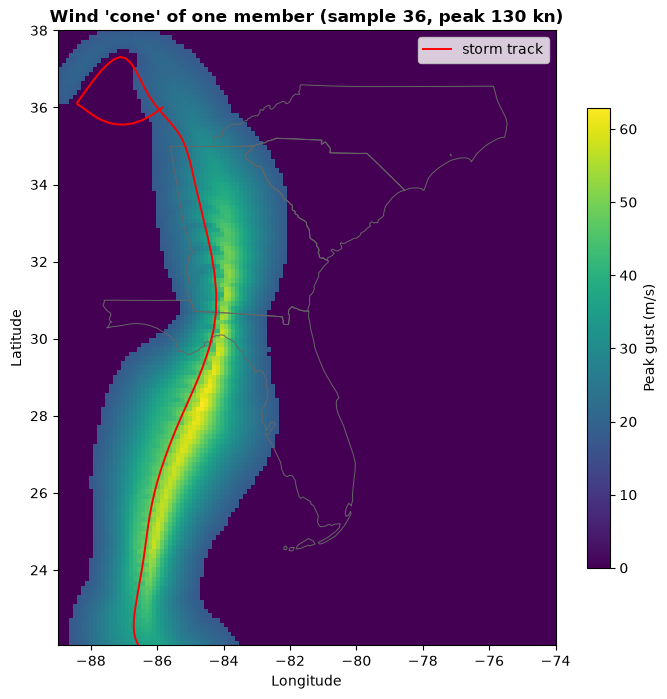

In [18]:
# --- Compute one member's wind field on a fine grid, purely to visualize it --
# ⏱️ ~15-30 s for this single member on the 0.12° grid.
# Pick the strongest member (most dramatic cone).
_peak = al.groupby("sample").maximum_sustained_wind_speed_knots.max()
_strongest = _peak.idxmax()

_one = weathernext_csv_to_tctracks(HAZARD_CSV)          # all members...
_one.data = [d for d in _one.data if d.attrs["sid"] == f"AL97_m{int(_strongest)}"]  # ...keep the strongest

# A fine grid of centroids over the storm's path (the CLIMADA-demo pattern).
from climada.hazard import Centroids, TropCyclone
_grid = Centroids.from_pnt_bounds((-89.0, 22.0, -74.0, 38.0), res=0.12)
_tc_one = TropCyclone.from_tracks(_one, centroids=_grid)

# Reshape the sparse intensity onto the raster for a clean filled plot.
_w = np.asarray(_tc_one.intensity.todense()).flatten()
_lon, _lat = _grid.lon, _grid.lat
_ny, _nx = np.unique(_lat).size, np.unique(_lon).size
_W = _w[np.lexsort((_lon, _lat))].reshape(_ny, _nx)
_extent = [_lon.min(), _lon.max(), _lat.min(), _lat.max()]
_tl = _one.data[0]

fig, ax = plt.subplots(figsize=(7, 8))
im = ax.imshow(_W, origin="lower", extent=_extent, cmap="viridis", aspect="equal")
fig.colorbar(im, ax=ax, shrink=0.6, label="Peak gust (m/s)")

# Clean state outlines (buffer trick removes hairline interior county lines).
_states = gpd.read_file(DATA_DIR / "counties_fl_ga_sc_nc.geojson")
_states["geometry"] = _states.geometry.buffer(0.005)
_states = _states.dissolve(by="state_fips")
_states["geometry"] = _states.geometry.buffer(-0.005)
_states.boundary.plot(ax=ax, color="0.4", linewidth=0.7, zorder=5)

ax.plot(_tl.lon, _tl.lat, color="red", lw=1.4, zorder=6, label="storm track")
ax.set_xlim(_lon.min(), _lon.max()); ax.set_ylim(_lat.min(), _lat.max())
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title(f"Wind 'cone' of one member (sample {int(_strongest)}, "
             f"peak {_peak[_strongest]:.0f} kn)", fontsize=12, fontweight="bold")
ax.legend(loc="upper right")
plt.tight_layout(); plt.show()

Notice the peak gust band hugs the **right-hand side** of the track — that's physically expected in the Northern Hemisphere, where the storm's forward motion *adds* to its counter-clockwise rotation on the right flank. And notice how **broad and smooth** the cone is: when we collapse it to one value per county, two homes in the same county get the same wind even if one sat in the bright core and the other on the faint edge. That is the simplification we accepted for speed.

## Step 4 · Build the exposure (what can be damaged)

> **Exposure** = the assets at risk and their dollar value. We use **single-family homes per county × an assumed value per home.**

We assign each county a single value = `n_single_family_homes × VALUE_PER_HOME`, located at the county point, and tag it with `impf_TC = 1` (the id of the damage function it should use, defined in Step 5).

In [19]:
# --- The one big assumption, in one obvious place ----------------------------
VALUE_PER_HOME = 300_000      # USD — a FLAT PLACEHOLDER (see the note below)

> 🌱 **Responsible-use note.** `VALUE_PER_HOME` is a single flat number for *every* home in *every* county — a teaching simplification. A real institution would use its **internal book of exposure**: actual insured values, replacement costs, or outstanding loan balances, which vary enormously between a Miami waterfront condo and a rural Georgia bungalow. This flat assumption will distort the dollar geography of the result; we accept it here only because the *method* is the lesson.

In [20]:
# --- Build the CLIMADA Exposures object --------------------------------------
from climada.entity import Exposures

exp_gdf = gpd.GeoDataFrame(
    {
        "value": homes["n_single_family_homes"] * VALUE_PER_HOME,
        "latitude": homes["latitude"],
        "longitude": homes["longitude"],
        "fips": homes["fips"],
        "impf_TC": 1,                       # use damage function id=1 (Step 5)
    },
    geometry=gpd.points_from_xy(homes["longitude"], homes["latitude"]),
    crs="EPSG:4326",
)
exp = Exposures(exp_gdf)
exp.check()
print(f"✓ exposure: {len(exp.gdf)} counties, "
      f"total insured value ${exp.gdf['value'].sum()/1e9:,.0f}B")

✓ exposure: 372 counties, total insured value $3,894B


## Step 5 · Define vulnerability (the **damage function**)

> **Vulnerability / damage function** = how much of an asset's value is lost at a given hazard intensity. It maps **wind speed → mean damage ratio** (a fraction from 0 to 1).

Real wind damage curves are roughly **sigmoidal**: almost no damage below tropical-storm force (~50 mph), a steep rise through hurricane intensities, and near-total loss by ~150–175 mph. We anchor a USACE/HAZUS-style residential curve at a handful of points, **specify it in mph** (how such curves are usually published), then convert the intensity axis to **m/s** for CLIMADA (`1 mph = 0.44704 m/s`).

In CLIMADA's `ImpactFunc`: `mdd` (mean damage degree) is the damage-ratio curve, and we set `paa = 1` (we assume the whole asset is potentially affected).

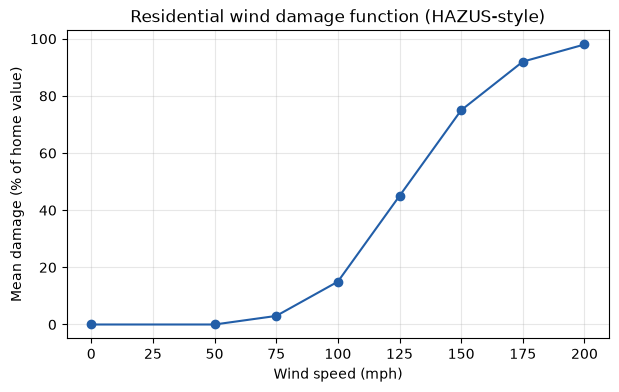

In [21]:
# --- Define the residential wind damage function -----------------------------
from climada.entity import ImpactFunc, ImpactFuncSet

MPH_TO_MS = 0.44704

# USACE/HAZUS-style anchor points: (wind mph, mean damage ratio 0-1)
curve_mph = np.array([ 0,  50,  75, 100, 125, 150, 175, 200])
curve_mdd = np.array([0.0, 0.00, 0.03, 0.15, 0.45, 0.75, 0.92, 0.98])

impf = ImpactFunc(
    haz_type="TC", id=1, name="HAZUS-style residential wind",
    intensity=curve_mph * MPH_TO_MS,        # convert the x-axis to m/s for CLIMADA
    mdd=curve_mdd,
    paa=np.ones_like(curve_mdd),            # paa = 1 (whole asset potentially affected)
    intensity_unit="m/s",
)
impf_set = ImpactFuncSet([impf])
impf_set.check()

# Plot the curve in the familiar mph units
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(curve_mph, curve_mdd * 100, "o-", color="#225ea8")
ax.set_xlabel("Wind speed (mph)"); ax.set_ylabel("Mean damage (% of home value)")
ax.set_title("Residential wind damage function (HAZUS-style)")
ax.grid(alpha=0.3); plt.show()

> ⚠️ **A real modeling assumption to name.** CLIMADA's wind intensity is a **gust** (m/s); published damage curves are often defined for **sustained** or **3-second-gust** speeds. Mixing them is a genuine source of error in catastrophe modeling — not a rounding detail. We proceed with the gust values but flag the mismatch as a known limitation.

### ⭐ YOUR TURN! — Exercise 1: make the building stock more vulnerable

Older or poorly-built housing is damaged at *lower* wind speeds. **Shift the damage curve left** — imagine homes that start taking serious damage at 90 mph instead of 125 mph — and rebuild the impact function. (You'll see the loss/VaR consequence after Step 6.)

*Hint: lower the wind speeds at which `mdd` ramps up, e.g. push the 0.45 and 0.75 points to lower mph. Keep values in [0, 1] and non-decreasing.*

In [22]:
# ⭐ YOUR TURN (Exercise 1): build a MORE vulnerable curve `impf_set_weak`.
# Start from the originals and shift the ramp to lower wind speeds.
curve_mph_weak = np.array([0, 50, 75, 100, 125, 150, 175, 200])
curve_mdd_weak = curve_mdd.copy()        # ← edit this so damage rises sooner

# ... build impf_weak (id=1, haz_type="TC") and impf_set_weak here ...

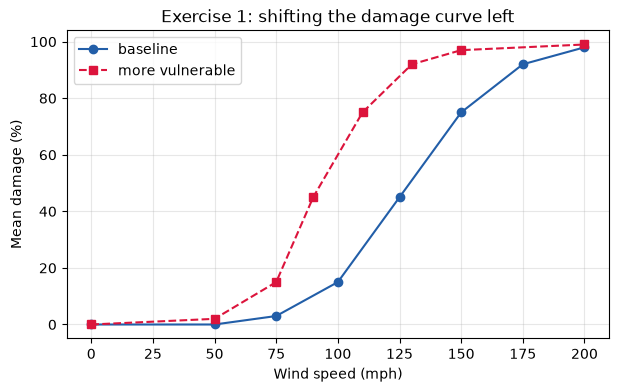

A left-shifted curve means the SAME forecast winds now cause MORE damage → higher VaR.


In [23]:
# @title 💡 Solution — Exercise 1
# --- Solution: a curve that ramps up ~35 mph earlier ------------------------
curve_mph_weak = np.array([0,  50,  75,  90, 110, 130, 150, 200])   # ramp shifted left
curve_mdd_weak = np.array([0.0, 0.02, 0.15, 0.45, 0.75, 0.92, 0.97, 0.99])

impf_weak = ImpactFunc(
    haz_type="TC", id=1, name="More-vulnerable residential wind",
    intensity=curve_mph_weak * MPH_TO_MS, mdd=curve_mdd_weak,
    paa=np.ones_like(curve_mdd_weak), intensity_unit="m/s",
)
impf_set_weak = ImpactFuncSet([impf_weak])
impf_set_weak.check()

plt.figure(figsize=(7, 4))
plt.plot(curve_mph, curve_mdd * 100, "o-", label="baseline", color="#225ea8")
plt.plot(curve_mph_weak, curve_mdd_weak * 100, "s--", label="more vulnerable", color="crimson")
plt.xlabel("Wind speed (mph)"); plt.ylabel("Mean damage (%)")
plt.legend(); plt.title("Exercise 1: shifting the damage curve left"); plt.grid(alpha=0.3)
plt.show()
print("A left-shifted curve means the SAME forecast winds now cause MORE damage → higher VaR.")

</details>

## Step 6 · Compute per-member, per-county loss

> **Loss** = exposure value × damage ratio, summed appropriately. With `save_mat=True`, CLIMADA returns the full **(events × exposures)** loss matrix — i.e. a loss number for **every county under every ensemble member**. That matrix *is* our distribution.

In [24]:
# --- Run the impact engine; keep the full per-member matrix ------------------
from climada.engine import ImpactCalc

if USE_CLIMADA_HAZARD:
    imp = ImpactCalc(exp, impf_set, haz).impact(save_mat=True)
    loss_mat = imp.imp_mat.toarray()                       # (events × counties), USD
else:
    # Apply the damage curve directly to the Holland wind field for the fallback.
    dmg = np.interp(intensity.toarray(), curve_mph * MPH_TO_MS, curve_mdd)
    loss_mat = dmg * exp.gdf["value"].values[None, :]

assert loss_mat.shape == (N_MEMBERS, len(homes)) and (loss_mat >= 0).all()
print(f"✓ loss matrix: {loss_mat.shape} (members × counties)")
print(f"  total modeled loss ranges ${loss_mat.sum(axis=1).min()/1e9:,.1f}B – "
      f"${loss_mat.sum(axis=1).max()/1e9:,.1f}B across the 50 forecast members")

✓ loss matrix: (48, 372) (members × counties)
  total modeled loss ranges $5.3B – $92.3B across the 50 forecast members


## Step 7 · From losses to Value-at-Risk

Now the payoff. For each county we have **N loss numbers** (one per equally-likely member) — a *distribution*. The **VaR at confidence level p** is simply the **p-th percentile** of that county's column.

We also compute the **ensemble mean** loss per county, to make a point that sits at the heart of risk management: **the mean hides the tail.**

In [25]:
# --- VaR (a percentile) and the mean, per county -----------------------------
VAR_PERCENTILE = 95          # ← the confidence level. Exposed for Exercise 2.

homes["var_loss"]  = np.percentile(loss_mat, VAR_PERCENTILE, axis=0)
homes["mean_loss"] = loss_mat.mean(axis=0)

total_var  = homes["var_loss"].sum()
total_mean = homes["mean_loss"].sum()
print(f"Portfolio {VAR_PERCENTILE}% wind VaR : ${total_var/1e9:,.1f}B")
print(f"Portfolio ensemble-MEAN loss   : ${total_mean/1e9:,.1f}B")
print(f"→ the VaR is {total_var/total_mean:.2f}× the mean: the tail the mean would hide.")

Portfolio 95% wind VaR : $117.5B
Portfolio ensemble-MEAN loss   : $30.9B
→ the VaR is 3.80× the mean: the tail the mean would hide.


> 🤔 **Check your understanding.** The 95% VaR is *larger* than the mean. Why is that the whole point? *(Because an institution must hold reserves for a **bad** outcome, not an **average** one. Sizing reserves to the mean leaves you under-provisioned exactly when a costly member verifies.)*

### ⭐ YOUR TURN! — Exercise 2: the percentile is a policy choice

The choice of percentile is not a technicality — it encodes how risk-averse the institution is. **Compute the portfolio loss at the 50th, 95th, and 99th percentiles, and compare each to the ensemble mean.** What happens to the headline number as you demand more confidence?

In [26]:
# ⭐ YOUR TURN (Exercise 2): fill in the percentiles and compare to the mean.
# Replace `None` with your calculation, then re-run this cell.
for p in [50, 95, 99]:
    total_p = None     # ← portfolio loss at percentile p (sum across counties)
    if total_p is None:
        print(f"{p}th percentile: (fill me in!)")
    else:
        print(f"{p}th percentile portfolio loss: ${total_p/1e9:,.1f}B")
# tip: also print the ensemble mean for comparison

50th percentile: (fill me in!)
95th percentile: (fill me in!)
99th percentile: (fill me in!)


In [27]:
# @title 💡 Solution — Exercise 2
# --- Solution: VaR rises sharply as you demand more confidence ---------------
for p in [50, 95, 99]:
    total_p = np.percentile(loss_mat, p, axis=0).sum()
    print(f"{p:>2}th percentile portfolio loss: ${total_p/1e9:,.1f}B")
print(f"     ensemble-mean portfolio loss: ${loss_mat.mean(axis=0).sum()/1e9:,.1f}B")
print()
print("The 99th-percentile (deep-tail) loss is far above the median and the mean. "
      "An ensemble lets you SEE that tail; a single forecast cannot.")

50th percentile portfolio loss: $13.2B
95th percentile portfolio loss: $117.5B
99th percentile portfolio loss: $197.0B
     ensemble-mean portfolio loss: $30.9B

The 99th-percentile (deep-tail) loss is far above the median and the mean. An ensemble lets you SEE that tail; a single forecast cannot.


</details>

> 💡 A single deterministic forecast gives one number — somewhere near the middle of this distribution. Only because we ran an *ensemble* can we report a 99th-percentile tail loss at all. That is why generative/ensemble AI weather models are a natural fit for forward-looking Climate VaR.

## Step 8 · The Value-at-Risk map

Finally, the headline deliverable: a **county choropleth** of the per-county wind VaR, with the ensemble member tracks overlaid in red so you can see the hazard that drove the losses.

In [28]:
# --- Join VaR onto county geometries -----------------------------------------
counties = gpd.read_file(DATA_DIR / "counties_fl_ga_sc_nc.geojson")
counties["fips"] = counties["fips"].astype(str).str.zfill(5)
gdf_map = counties.merge(homes[["fips", "var_loss", "mean_loss"]], on="fips", how="left")
gdf_map["var_k"] = gdf_map["var_loss"] / 1e3        # express legend in $thousands
print(f"✓ joined VaR onto {gdf_map['var_loss'].notna().sum()} / {len(gdf_map)} counties")

✓ joined VaR onto 372 / 372 counties


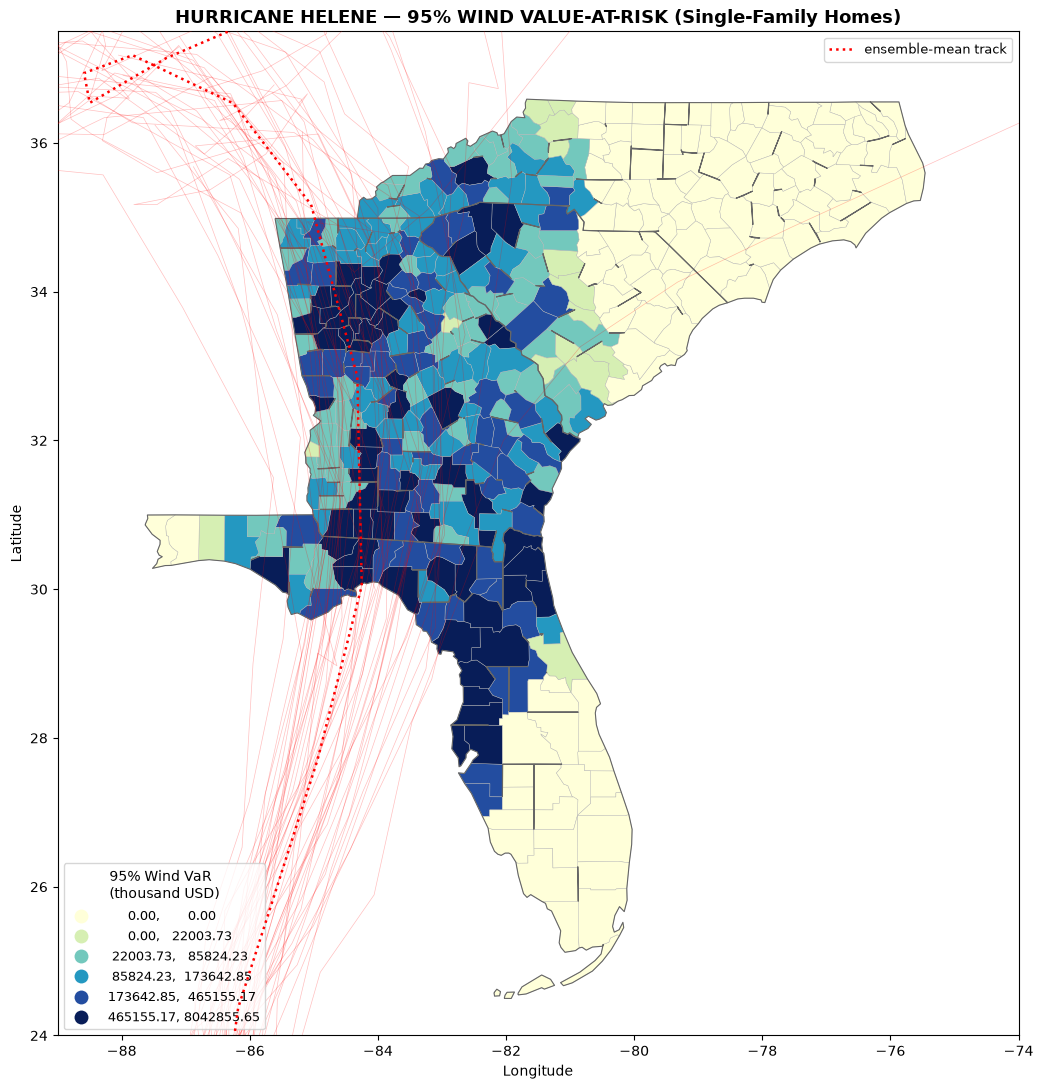

In [29]:
# --- The choropleth (YlGnBu, quantile bins, red track overlay) ---------------
fig, ax = plt.subplots(figsize=(11, 11))

# quantile (binned) legend so the spread is readable
gdf_map.plot(
    column="var_k", cmap="YlGnBu", scheme="quantiles", k=6,
    linewidth=0.3, edgecolor="0.7", legend=True, ax=ax,
    legend_kwds={"title": f"{VAR_PERCENTILE}% Wind VaR\n(thousand USD)",
                 "loc": "lower left", "fontsize": 9},
    missing_kwds={"color": "lightgrey", "label": "no data"},
)

# light-gray state outlines
counties.dissolve(by="state_fips").boundary.plot(ax=ax, color="0.4", linewidth=0.8)

# overlay ensemble member tracks as thin, semi-transparent red lines
for s, g in al.groupby("sample"):
    g = g.sort_values("valid_time")
    ax.plot(g.lon, g.lat, color="red", lw=0.5, alpha=0.25, zorder=5)
# ensemble-mean track as a red dotted line
mean_track = (al.groupby(al.groupby("sample").cumcount())[["lat", "lon"]].mean())
ax.plot(mean_track.lon, mean_track.lat, "r:", lw=1.8, zorder=6, label="ensemble-mean track")

ax.set_title(f"HURRICANE HELENE — {VAR_PERCENTILE}% WIND VALUE-AT-RISK (Single-Family Homes)",
             fontsize=13, fontweight="bold")
ax.set_xlim(-89, -74); ax.set_ylim(24, 37.5)
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
choropleth_legend = ax.get_legend()   # grab it right after gdf_map.plot()
ax.add_artist(choropleth_legend)      # re-attach so it survives the next ax.legend() call
ax.legend(loc="upper right", fontsize=9)  # now safe to add the track legend
plt.tight_layout(); plt.show()

The VaR is **concentrated in Florida and Georgia** — under the dense bundle of red tracks — and **fades through the Carolinas**. That spatial story is correct *for wind*… and it is the setup for the most important lesson in this tutorial.

## 9 · Interpretation, limitations & responsible use

### 🚨 The headline lesson: this map is *hot where Helene's damage wasn't*

Our ensemble shows wind **peaking in Florida (90–130 kn across members) and Georgia (≈Cat-1 median)**, then tapering to tropical-storm force in **South and North Carolina**. So our **wind-only** VaR map is hot in FL/GA and cool in the Carolinas.

That is **the opposite of where Hurricane Helene's worst real-world damage actually occurred.** Helene's catastrophic losses were in **western North Carolina and the southern Appalachians** — driven by **inland flooding and extreme rainfall**, a peril this pipeline **does not model at all**.

Walk through what that means:

- **✅ What the method *can* tell you:** the relative **wind-loss** exposure across counties, and — crucially — its **spread** across forecast scenarios (the VaR vs. the mean). For wind-dominated events and assets, this is genuinely useful.
- **❌ What it *cannot*:** flood, storm surge, or compound (wind + water) losses. It will **systematically understate** the Carolinas, where the real catastrophe happened.
- **⚖️ Who is harmed if it's trusted blindly:** an institution that sized its Helene reserves on **wind VaR alone** would have **under-provisioned** for the Appalachian flood disaster — failing policyholders and borrowers precisely where the loss landed.
- **🧭 What's needed before real use:** coupled **flood and storm-surge** models; **validated** vulnerability curves (calibrated to real claims, with the gust-vs-sustained issue resolved); **real exposure** data (actual insured values, not a flat \$300k); and **governance** — expert review, model validation, and clear documentation of scope.

> 🌱 **Responsible AI, concretely.** The failure here is not a bug in the code — every cell ran correctly. It is a **scope** failure: a faithful answer to the wrong question. The most dangerous climate-risk models are the ones that are *right about what they model* and silent about what they omit. Stating the boundary of validity is not a footnote; it is the deliverable.

### Other limitations

- **One point per county** ignores intra-county wind variation (coast vs. inland).
- **Flat home value** distorts the dollar geography (Miami ≠ rural Georgia).
- **Forecast, not observation:** the ensemble is a ~3-day-out genesis forecast; the real storm may have verified outside the ensemble entirely.
- **Event VaR, not annual:** this is one storm's forward-looking spread, *not* an Average Annual Loss.

### Further work
> 🔬 **Where machine learning could extend this pipeline.** Each downstream stage can itself be learned rather than assumed. The vulnerability curve could be a model trained on observed claims; exposure values could be estimated from imagery or property records; and the financial step could forecast losses, premiums, or reserves conditioned on the hazard ensemble. The main barrier is data: high-quality loss data is typically proprietary, held by insurers and reinsurers, which is why open examples like this one use a published damage function instead of a learned one. Building any of these into the chain — especially a data-driven vulnerability model — is a natural next project.


> 🔬 **(Optional, advanced) Take it further.** Replace the one-point-per-county centroids with a regular **0.1° grid** over the four states (`Centroids.from_pnt_bounds`), re-run the wind field and impact, then aggregate losses back to counties. Does the finer hazard resolution change which counties dominate the VaR? *(This increases run time — try it after the smoke test passes.)*

## 10 · Energy & emissions (CodeCarbon)

Climate work has its own carbon footprint. We wrapped the compute-heavy section (Steps 3–7) in a CodeCarbon `EmissionsTracker`. The cell below reports the estimate. On Colab the underlying hardware power draw is often not readable — we catch that and report "unavailable" rather than crash.

> 📝 *Note for the build:* in this notebook the tracker is started just before Step 3 and stopped here. If you re-run individual cells out of order the number is approximate.

In [30]:
# --- Stop the tracker, then report (gracefully handle missing power readings) -
try:
    if globals().get("_tracker") is not None:
        _emissions_kg = _tracker.stop()      # kg CO2e, or None/0 if unreadable
except Exception as _e:
    print(f"CodeCarbon stop failed (non-fatal): {_e}")

try:
    emissions_kg = globals().get("_emissions_kg", None)
    if emissions_kg is None:
        print("CodeCarbon: tracker did not run in this session (run all cells in order).")
    elif emissions_kg <= 0:
        print("CodeCarbon: hardware power readings unavailable on this runtime "
              "(common on Colab) — emissions estimated/unavailable.")
    else:
        print(f"CodeCarbon: estimated {emissions_kg*1000:.2f} g CO₂e for the compute section.")
        print("For scale, that is far less than a single web search — but at scale, "
              "ensemble catastrophe modeling adds up. Worth tracking.")
except Exception as e:
    print(f"CodeCarbon summary unavailable: {e}")

CodeCarbon: tracker did not run in this session (run all cells in order).


## 11 · References & further reading

- **CLIMADA** — Aznar-Siguan, G. & Bresch, D. N. (2019). *CLIMADA v1: a global weather and climate risk assessment platform.* Geosci. Model Dev. 12, 3085–3097. <https://climada.ethz.ch/>
- **WeatherNext** — Google DeepMind WeatherNext / GenCast cyclone products. Data under **CC BY 4.0** (for data >48 h old); attribute Google. <https://deepmind.google/science/weathernext/>
- **Holland (1980)** — *An Analytic Model of the Wind and Pressure Profiles in Hurricanes.* Mon. Wea. Rev. 108, 1212–1218.
- **HAZUS** — FEMA Hazus Hurricane Model Technical Manual (residential wind vulnerability).
- **US Census ACS** — Table B25024 (units in structure), 5-year estimates. <https://data.census.gov/>
- **Value-at-Risk** — Jorion, P. *Value at Risk: The New Benchmark for Managing Financial Risk.*
- **Hurricane Helene (2024)** — NOAA National Hurricane Center Tropical Cyclone Report (for the wind-vs-flood damage attribution).

---

🎓 **You did it.** You took a 50-member AI weather ensemble, ran it through the full hazard → exposure → vulnerability → loss chain, computed a per-county Value-at-Risk, mapped it — and, most importantly, learned to say out loud what the map *cannot* tell you. That last skill is the one the field needs most.